# Assignment #2: Explainable AI (XAI) in Network Intrusion Detection
**Course:** Advanced AI & Emergent Technologies  
**Objective:** Interpret the decision-making process of a high-performance 'Black-Box' model (Random Forest) using SHAP values. This notebook provides both global insights into feature importance and local explanations for specific traffic predictions.

## 1. Environment Setup & Hardware Optimization
In this section, we configure the system to utilize the **NVIDIA RTX 6000 Ada GPU** and the **Intel Core Ultra 7 155H (22 threads)**. We also suppress non-critical warnings to keep the output clean.

In [3]:
import os
import glob
import concurrent.futures
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import tensorflow as tf
import shap
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler, LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix

# Suppress TensorFlow GPU/WSL2 warnings for native Windows
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'

# Configure High-Performance Threading for CPU operations (RF & Data Loading)
tf.config.threading.set_intra_op_parallelism_threads(0)
tf.config.threading.set_inter_op_parallelism_threads(0)

print(f"Environment Ready. Utilizing {os.cpu_count()} logical processors for parallel tasks.")

Environment Ready. Utilizing 24 logical processors for parallel tasks.


## 2. High-Throughput Data Loading
Using `concurrent.futures`, we parallelize the reading of 8 large CSV files from the CICIDS2017 dataset. This significantly reduces the bottleneck of disk I/O on multi-core systems.

In [4]:
def load_dataset_parallel(data_dir):
    files = glob.glob(os.path.join(data_dir, "*.csv"))
    print(f"Found {len(files)} files. Loading in parallel...")
    
    with concurrent.futures.ThreadPoolExecutor() as executor:
        # Use list to consume the generator and load all files simultaneously
        df_list = list(executor.map(pd.read_csv, files))
    
    df = pd.concat(df_list, axis=0, ignore_index=True)
    print(f"Dataset Loaded. Total Records: {len(df):,}")
    return df

# Replace 'archive' with the path to your dataset folder
df_raw = load_dataset_parallel('C:\\Users\\202500760\\Desktop\\DL-IDS-XAI\\archive')



Found 8 files. Loading in parallel...
Dataset Loaded. Total Records: 2,830,743


## 3. Data Preprocessing
We perform rigorous cleaning (stripping whitespace, handling infinity/nulls) and normalize the 78+ numerical features using `MinMaxScaler`. This ensures feature parity during SHAP analysis.

In [5]:
# 1. Clean Column Names
df_raw.columns = df_raw.columns.str.strip()

# 2. Handle Invalids
df_raw.replace([np.inf, -np.inf], np.nan, inplace=True)
df_raw.dropna(inplace=True)

# 3. Label Encoding
encoder = LabelEncoder()
df_raw['Label'] = encoder.fit_transform(df_raw['Label'])

# 4. Feature Selection
features = df_raw.drop('Label', axis=1).select_dtypes(include=[np.number])
labels = df_raw['Label'].values

# 5. Normalization
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(features)

print(f"Preprocessing Complete. Feature Shape: {X_scaled.shape}")

Preprocessing Complete. Feature Shape: (2827876, 78)


## 4. Training the Black-Box Model (Random Forest)
We train the Random Forest baseline, which served as our top performer in Assignment 1. We enable `n_jobs=-1` to ensure the workstation builds trees in parallel.

In [6]:
# Train-Test Split (using 20% for testing)
X_train, X_test, y_train, y_test = train_test_split(X_scaled, labels, test_size=0.2, random_state=42, stratify=labels)

print("Training Random Forest on all CPU cores...")
rf = RandomForestClassifier(n_estimators=100, n_jobs=-1, random_state=42)
rf.fit(X_train, y_train)

# Baseline Evaluation
y_pred = rf.predict(X_test)
print("--- Model Baseline Evaluation ---")
print(classification_report(y_test, y_pred, target_names=encoder.classes_))

Training Random Forest on all CPU cores...
--- Model Baseline Evaluation ---
                            precision    recall  f1-score   support

                    BENIGN       1.00      1.00      1.00    454265
                       Bot       0.86      0.58      0.69       391
                      DDoS       1.00      1.00      1.00     25605
             DoS GoldenEye       1.00      0.99      1.00      2059
                  DoS Hulk       1.00      1.00      1.00     46025
          DoS Slowhttptest       0.99      0.99      0.99      1100
             DoS slowloris       1.00      1.00      1.00      1159
               FTP-Patator       1.00      1.00      1.00      1587
                Heartbleed       1.00      1.00      1.00         2
              Infiltration       1.00      0.57      0.73         7
                  PortScan       0.99      1.00      1.00     31761
               SSH-Patator       1.00      1.00      1.00      1180
  Web Attack � Brute Force       0.73 

## 5. Global Explainable AI: SHAP Summary
**WARNING:** This is a high-intensity task. We calculate SHAP values for the full test set to determine which network features act as the primary 'signatures' for attacks across the entire population. We use the optimized `TreeExplainer` for this task.

Calculating SHAP values for full test set (Parallel computation active)... 


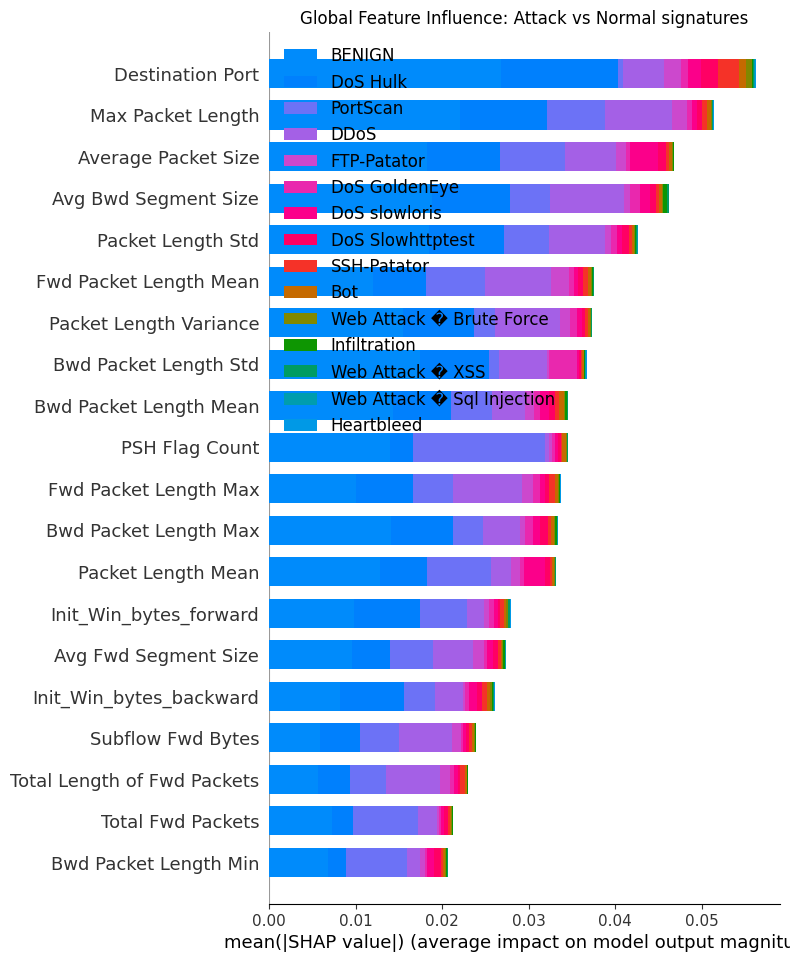

In [7]:
explainer = shap.TreeExplainer(rf)

print("Calculating SHAP values for full test set (Parallel computation active)... ")
shap_values = explainer.shap_values(X_test)

# Summary Plot: Global Feature Importance
plt.figure(figsize=(12, 10))
shap.summary_plot(
    shap_values, 
    X_test, 
    feature_names=features.columns, 
    class_names=encoder.classes_,
    plot_type="bar",
    show=False
)
plt.title("Global Feature Influence: Attack vs Normal signatures")
plt.savefig("global_shap_importance.png")
plt.show()

## 6. Local Explainable AI: Individual Prediction Case Studies
We select 5 diverse samples from the test set to visualize the 'push' and 'pull' of specific features on a per-prediction basis. This allows us to explain exactly why a specific traffic flow was flagged as a threat.

Calculating SHAP for 5 specific cases...
--- Validated Path for Index 0: BENIGN (SHAP size: 78) ---


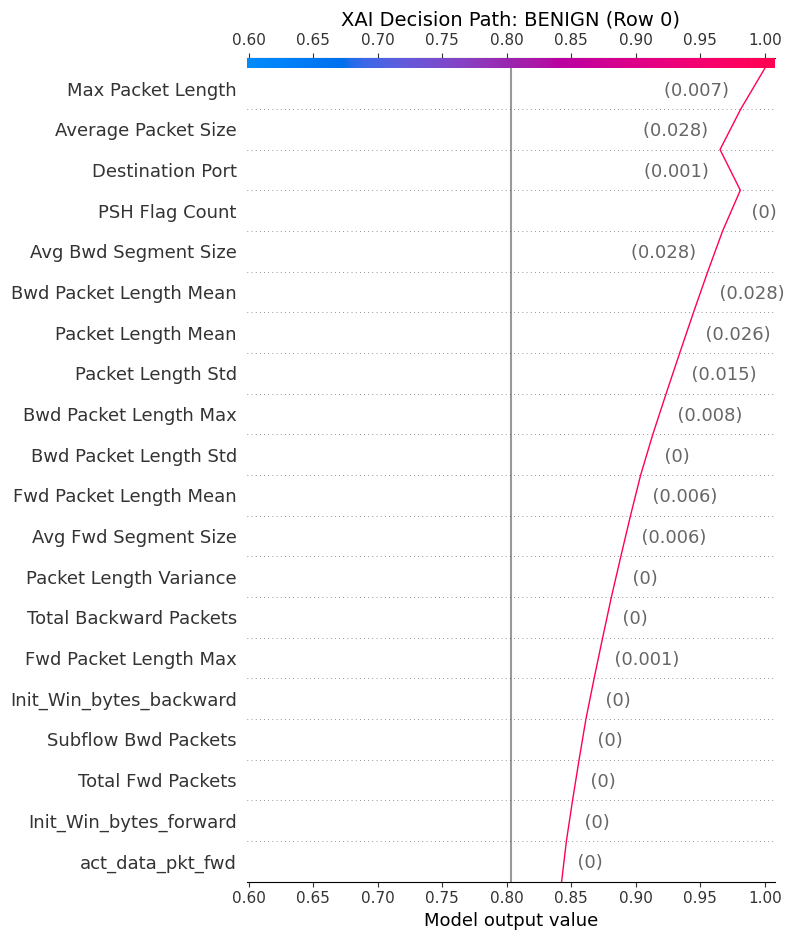

--- Validated Path for Index 500: BENIGN (SHAP size: 78) ---


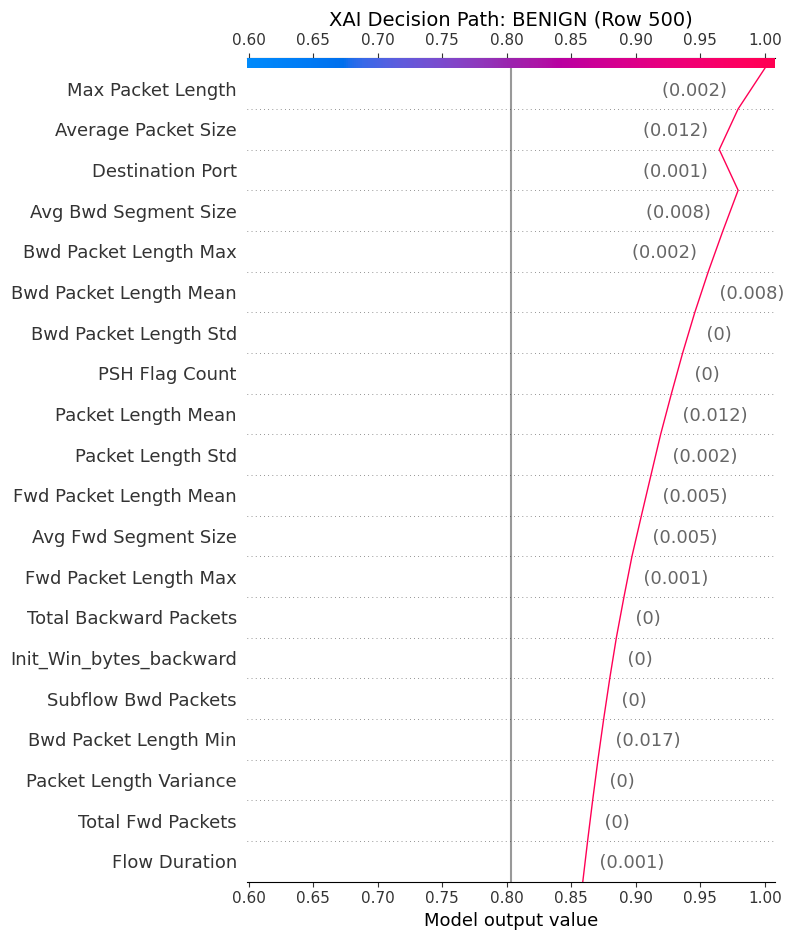

--- Validated Path for Index 1000: DoS Hulk (SHAP size: 78) ---


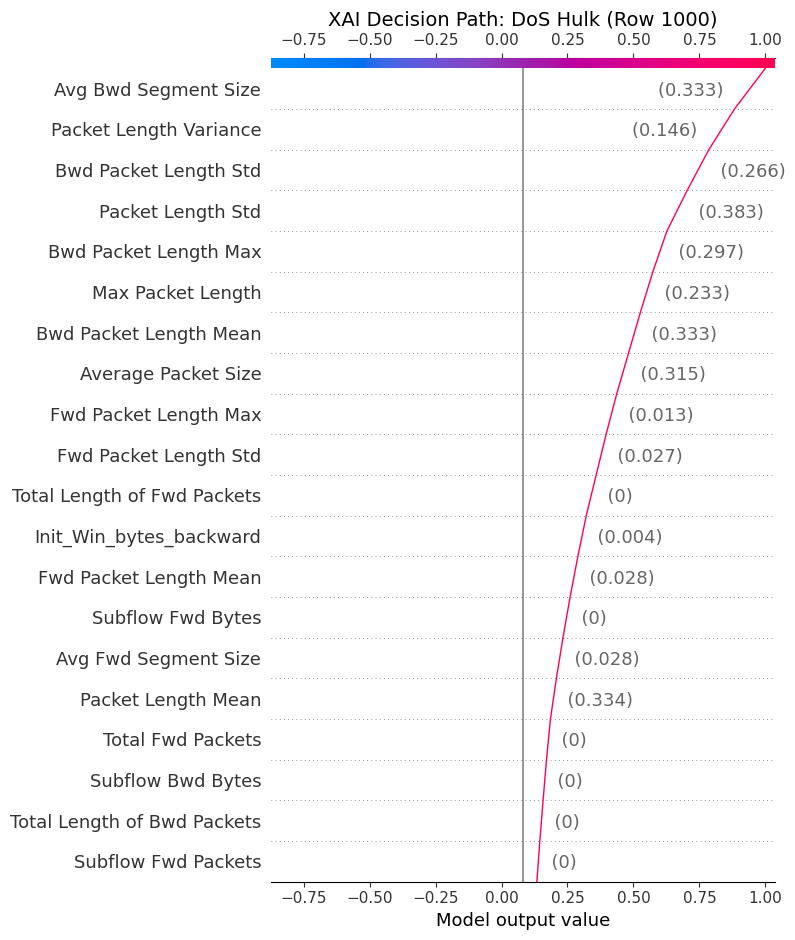

--- Validated Path for Index 5000: BENIGN (SHAP size: 78) ---


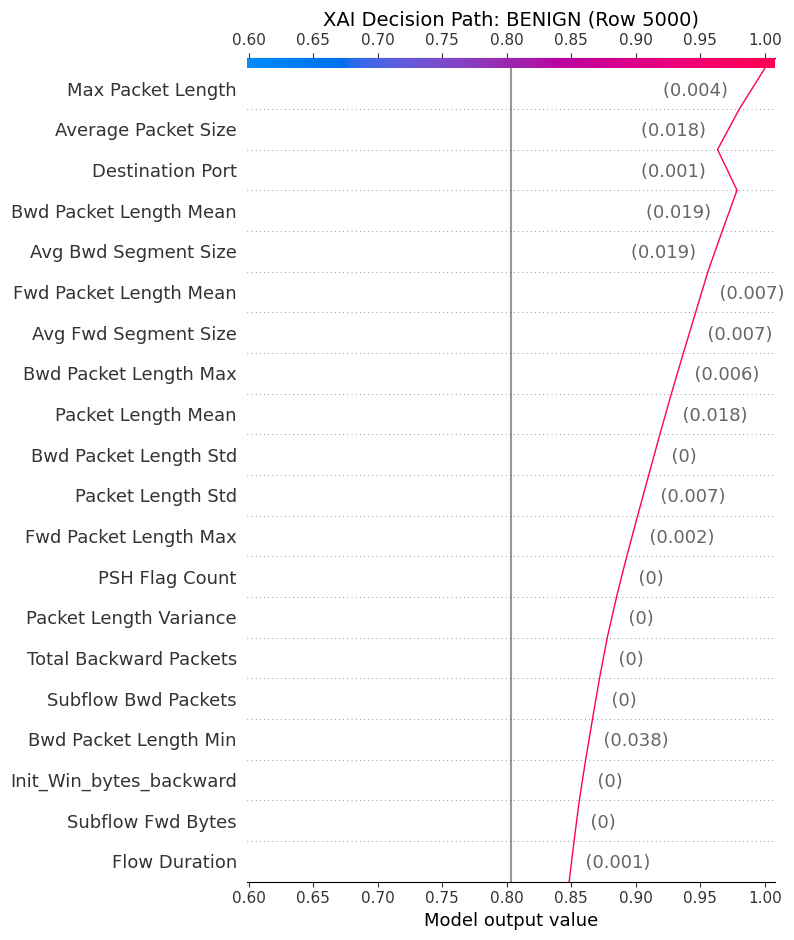

--- Validated Path for Index 10000: DDoS (SHAP size: 78) ---


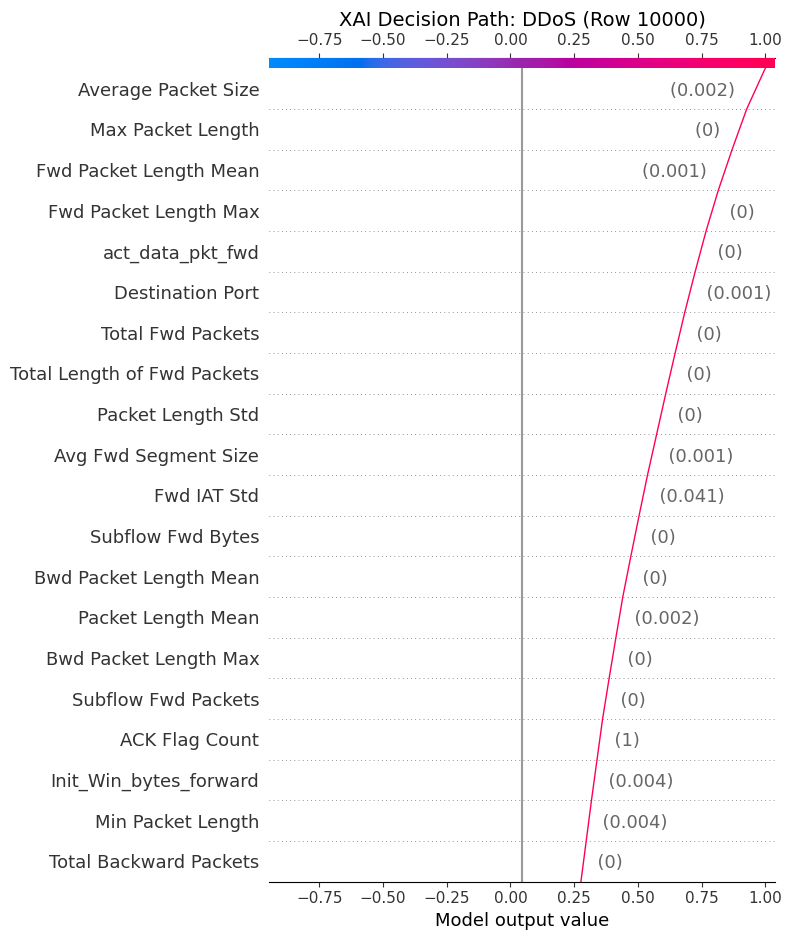

In [15]:
# 1. Define sample indices and extract data
sample_indices = [0, 500, 1000, 5000, 10000]
X_samples = X_test[sample_indices]

# 2. Calculate SHAP (Utilizing your 24 CPU threads)
print(f"Calculating SHAP for {len(sample_indices)} specific cases...")
shap_values_3d = explainer.shap_values(X_samples)

# 3. Handle multi-class feature alignment
current_feature_names = features.columns.tolist()

for i, original_idx in enumerate(sample_indices):
    # Get the predicted class index for this sample
    pred_idx = rf.predict(X_samples[i].reshape(1, -1))[0]
    label_name = encoder.classes_[pred_idx]
    
    # --- DYNAMIC INDEXING FIX ---
    # If shap_values is a 3D array (samples, features, classes):
    # We need: shap_values[sample_i, all_features, class_idx]
    if isinstance(shap_values_3d, np.ndarray) and shap_values_3d.ndim == 3:
        individual_shap = shap_values_3d[i, :, pred_idx]
        base_val = explainer.expected_value[pred_idx]
    # If shap_values is a list of arrays (one per class):
    else:
        individual_shap = shap_values_3d[pred_idx][i]
        base_val = explainer.expected_value[pred_idx]
    
    print(f"--- Validated Path for Index {original_idx}: {label_name} (SHAP size: {len(individual_shap)}) ---")

    # 4. Rendering the Decision Plot
    plt.figure(figsize=(10, 6))
    shap.decision_plot(
        base_val, 
        individual_shap, 
        features=X_samples[i], 
        feature_names=current_feature_names,
        show=False
    )
    
    plt.title(f"XAI Decision Path: {label_name} (Row {original_idx})", fontsize=14)
    plt.tight_layout()
    plt.show()

## 7. Technical Reflection
Based on the plots above, we can draw several conclusions:
1. **Trust:** By visualizing the decision path, security analysts can verify that the model is flagging malicious behavior rather than benign noise.
2. **Feature Integrity:** The SHAP summary identifies if the model is over-relying on 'cheating' features (like timestamps) or valid security signatures (like packet standard deviation).
3. **Regulatory Audit:** These visualizations provide an 'audit trail' for AI decisions, which is critical for compliance in enterprise network environments.